# INF-8239 · Ejercicio 03 · Corpus público y clasificador de texto reproducible

**Unidad 02 · Procesamiento de Lenguaje Natural**

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import json

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_colwidth", 120)
REPORTS = ROOT / "reports"
print("Raíz del proyecto:", ROOT)
print("Intérprete:", sys.executable)

Raíz del proyecto: /tmp/nlp/INF8239_U02_E03_NLP
Intérprete: /tmp/nlp/INF8239_U02_E03_NLP/.venv/bin/python


## 1. Obtención reproducible
Descarga los tres archivos del repositorio original en un **commit fijado**, verifica SHA-256 contra `data/raw_manifest.json` y construye `data/processed/corpus.csv` (v1.0) y `external_v2.csv` (v2.0).

In [ ]:
from scripts import download_data

assert download_data.main() == 0
manifest = json.loads((ROOT / "data/raw_manifest.json").read_text())
pd.DataFrame(manifest["files"])[["name", "file", "sha256"]]

Corpus principal: 971 filas -> data/processed/corpus.csv
Externo v2.0:     572 filas -> data/processed/external_v2.csv
  data/raw/train.xlsx  SHA-256 b091a8fa842ea4c2…
  data/raw/development.xlsx  SHA-256 5a894152170242cb…
  data/raw/test.xlsx  SHA-256 11e38355804f86cf…


,name,file,sha256
0,train,data/raw/train.xlsx,b091a8fa842ea4c2c9b9c28fe0ed28d6ed8da797ced282c5a4dcd71af2e3c67a
1,development,data/raw/development.xlsx,5a894152170242cb07248d264157b4d3884d86ef42e5ba22e5a6a638787dce57
2,external_v2,data/raw/test.xlsx,11e38355804f86cfac3aeddcb78208cb175d369831f551f9d8fe49353c582763


## 2. Auditoría: calidad, duplicados y fuga

In [ ]:
from scripts import audit_data

audit = audit_data.run()
summary = {k: audit[k] for k in ["rows", "label_distribution", "label_by_split", "empty_text",
                                 "duplicates", "sources", "pure_sources", "rows_in_pure_sources",
                                 "source_mentioned_in_text", "share_with_NUMBER_token_by_label",
                                 "leakage_source_only_model"]}
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "rows": 971,
  "label_distribution": {
    "true": 491,
    "fake": 480
  },
  "label_by_split": {
    "development": {
      "true": 153,
      "fake": 142
    },
    "train": {
      "fake": 338,
      "true": 338
    }
  },
  "empty_text": 0,
  "duplicates": {
    "exact_duplicates": 5,
    "normalized_duplicates": 5,
    "cross_development_train": 4,
    "duplicates_with_conflicting_label": 0
  },
  "sources": 150,
  "pure_sources": 147,
  "rows_in_pure_sources": 898,
  "source_mentioned_in_text": 70,
  "share_with_NUMBER_token_by_label": {
    "fake": 0.66,
    "true": 0.88
  },
  "leakage_source_only_model": {
    "f1_macro_mean": 0.9263986502149049,
    "f1_macro_std": 0.010054371293256646
  }
}


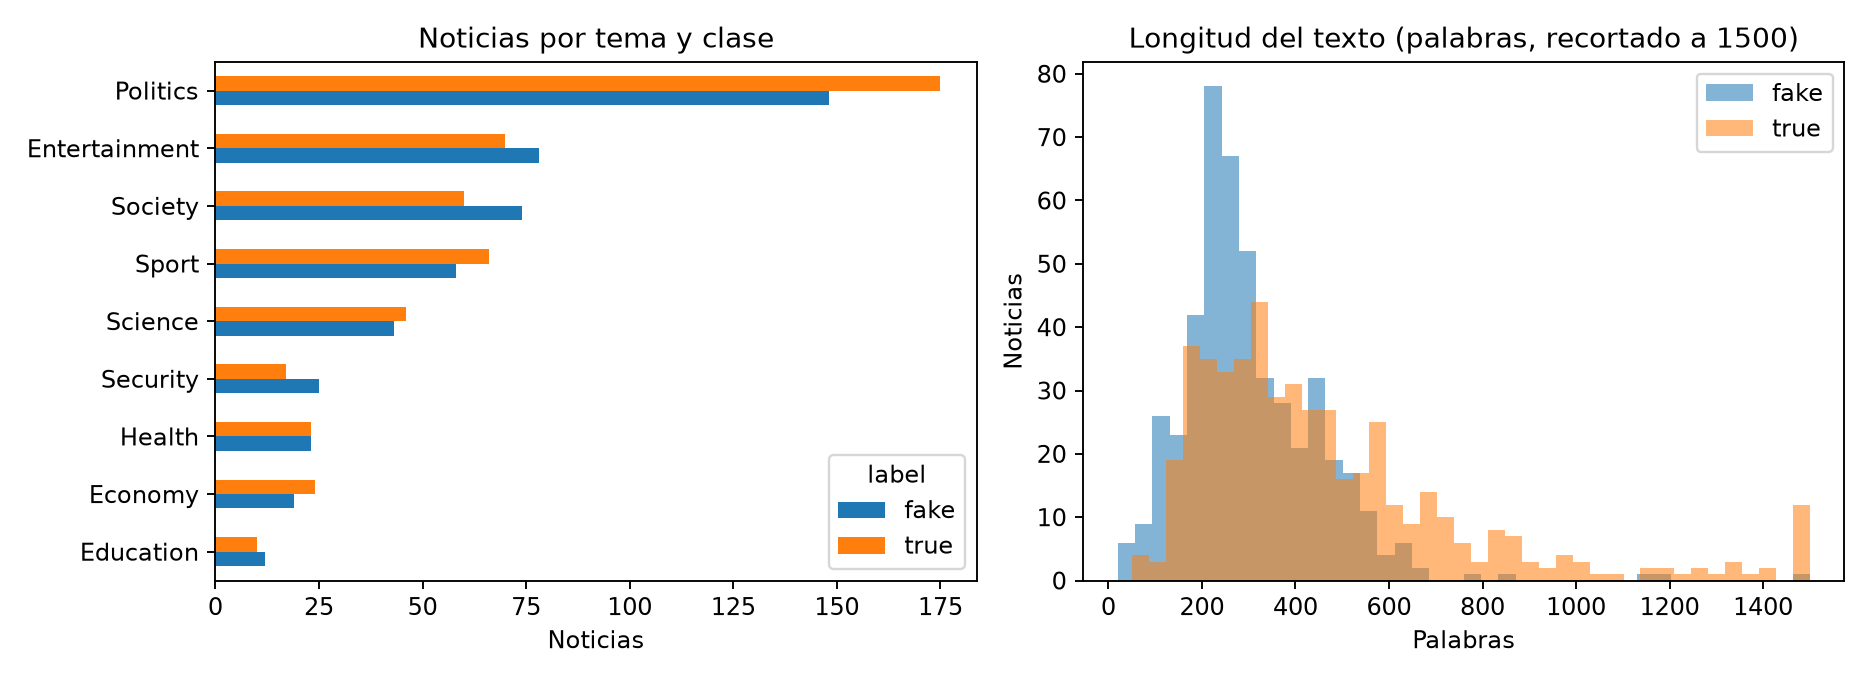

,source,rows,majority_label,purity
0,el dizque,135,fake,1.000000
1,el ruinaversal,94,fake,1.000000
2,el país,75,true,1.000000
3,el universal,69,true,0.985507
4,excelsior,45,true,1.000000
5,hay noticia,39,fake,1.000000
6,censura 0,36,fake,1.000000
7,forbes,34,true,1.000000
8,huffpost,26,true,1.000000
9,proceso,25,true,1.000000


In [ ]:
display(Image(REPORTS / "fig_audit_overview.png", width=900))
pd.read_csv(REPORTS / "audit_source_purity.csv").head(10)

**Lectura de la auditoría**

* No hay textos vacíos ni etiquetas nulas; las clases están balanceadas (480 `fake`, 491 `true`).
* Hay 5 duplicados: 4 entre `train` y `development` y 1 dentro de `development`. Ninguno con etiqueta contradictoria. Se eliminan de la prueba para que el modelo no sea evaluado con textos que ya vio.
* **Fuga por medio:** 147 de 150 medios publican una sola clase. Un modelo que solo conoce el nombre del medio alcanza un F1 macro ≈ 0.93. Por eso `source`, `link` e `id` **no** son predictores: el modelo recibe únicamente el texto.
* **Artefacto de formato:** la v1.0 reemplaza las cifras por `NUMBER` (más frecuente en las verdaderas) y la v2.0 conserva dígitos. El preprocesamiento convierte ambas formas en el token `number`.

## 3. Línea base, dos pipelines comparables y evaluación
Mismo conjunto de entrenamiento, misma validación cruzada (5 pliegues estratificados), búsqueda simétrica de `C` y la prueba se usa una sola vez.

In [ ]:
from scripts import train_text

results = train_text.run()
cols = ["model", "best_params", "cv_f1_macro_mean", "cv_f1_macro_std", "test_f1_macro",
        "test_f1_ci95_low", "test_f1_ci95_high", "recall_fake", "recall_true",
        "fit_median_s", "predict_ms_total", "size_kb", "selected"]
print("Partición:", results["split"])
results["table"][cols].round(4)

Partición: {'train_rows': 676, 'test_rows': 290, 'removed_dup_in_train': 0, 'removed_dup_in_test': 1, 'removed_cross_split': 4}


,model,best_params,cv_f1_macro_mean,cv_f1_macro_std,test_f1_macro,test_f1_ci95_low,test_f1_ci95_high,recall_fake,recall_true,fit_median_s,predict_ms_total,size_kb,selected
0,dummy,{},0.3320,0.0007,0.3240,0.2978,0.3512,1.0000,0.0000,0.7985,172.8702,763.0947,False
1,tfidf_word_logreg,"{""model__C"": 10.0}",0.8283,0.0281,0.7926,0.7436,0.8353,0.7770,0.8079,0.8737,232.4410,1017.0508,True
2,tfidf_char_svm,"{""model__C"": 1.0}",0.8343,0.0413,0.8029,0.7525,0.8481,0.7842,0.8212,2.9248,1016.8938,1554.0312,False


Regla de selección: regla de 1 error estándar sobre F1 macro CV en train; entre elegibles, menor tiempo de ajuste
Modelo seleccionado: tfidf_word_logreg
McNemar: {'only_a_correct': 14, 'only_b_correct': 17, 'p_value': 0.720100131817162}


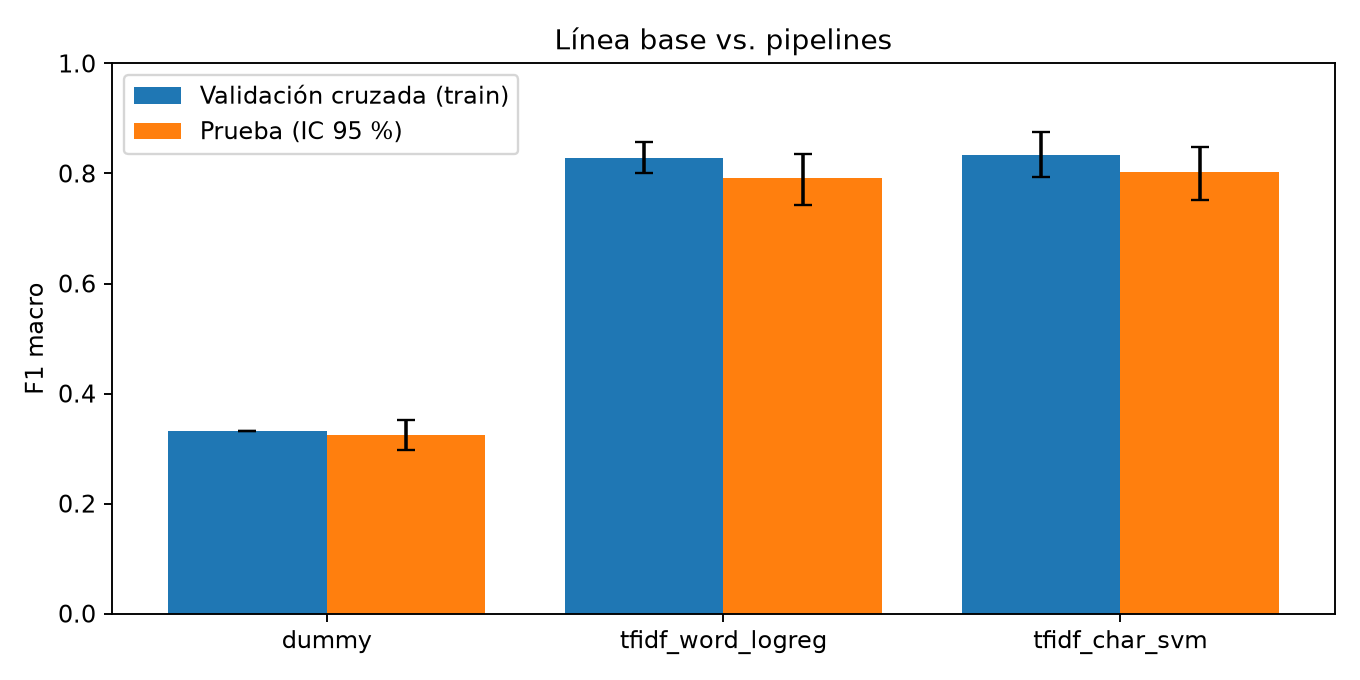

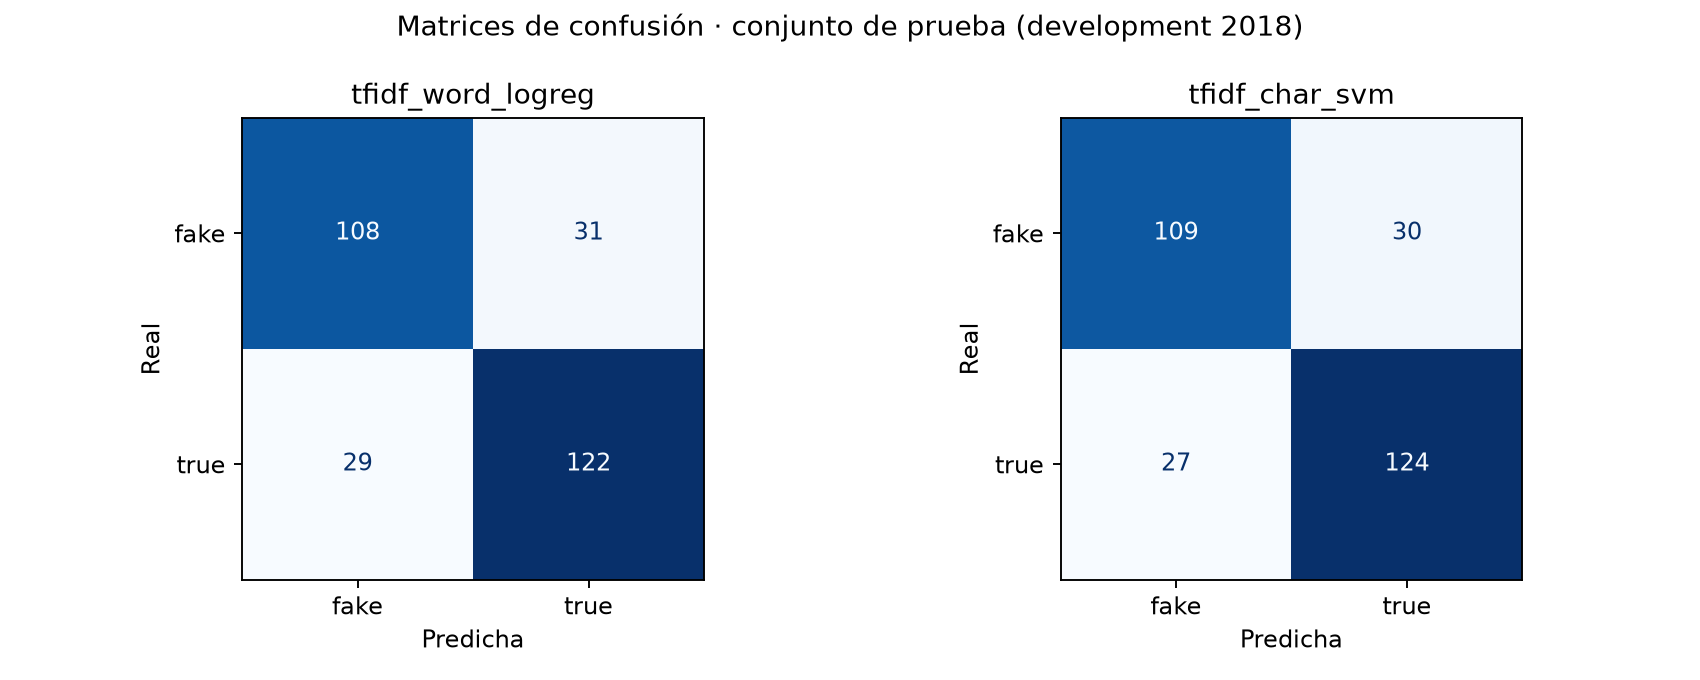

In [ ]:
print("Regla de selección:", results["selection_rule"])
print("Modelo seleccionado:", results["selected_model"])
key = next(k for k in results if k.startswith("mcnemar"))
print("McNemar:", results[key])
display(Image(REPORTS / "fig_model_comparison.png", width=750))
display(Image(REPORTS / "fig_confusion.png", width=850))

## 4. ¿Qué aprendió el modelo?

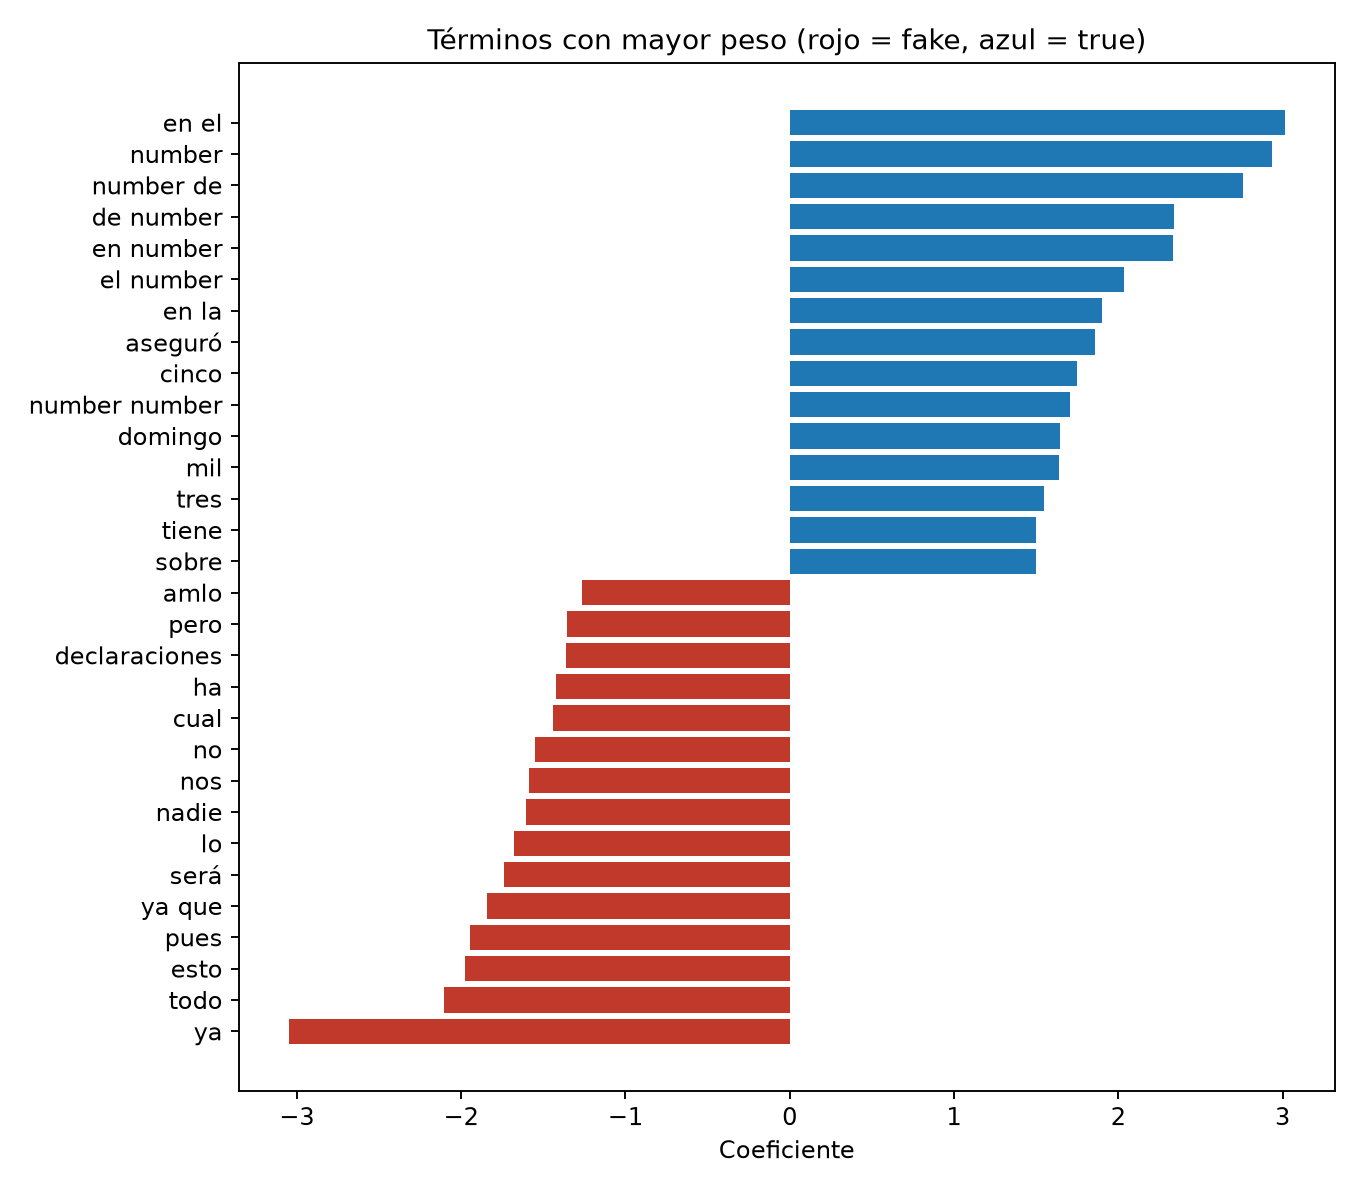

In [ ]:
display(Image(REPORTS / "fig_top_terms.png", width=650))

## 5. Generalización: medios no vistos y corpus posterior

,model,group_cv_f1_mean,group_cv_f1_std,folds
0,tfidf_word_logreg,0.7027,0.0851,"[0.6111, 0.8589, 0.652, 0.676, 0.7153]"
1,tfidf_char_svm,0.7050,0.0783,"[0.6145, 0.8486, 0.6634, 0.7006, 0.6977]"


{
  "accuracy": 0.6836,
  "f1_macro": 0.6725,
  "precision_fake": 0.7901,
  "recall_fake": 0.5,
  "f1_fake": 0.6124,
  "support_fake": 286,
  "precision_true": 0.6343,
  "recall_true": 0.8671,
  "f1_true": 0.7326,
  "support_true": 286,
  "rows": 572,
  "f1_ci95": [
    0.6312114119982939,
    0.7103520960840667
  ],
  "ablation_keep_digits_f1_macro": 0.7278,
  "ablation_keep_digits_recall_fake": 0.6608
}


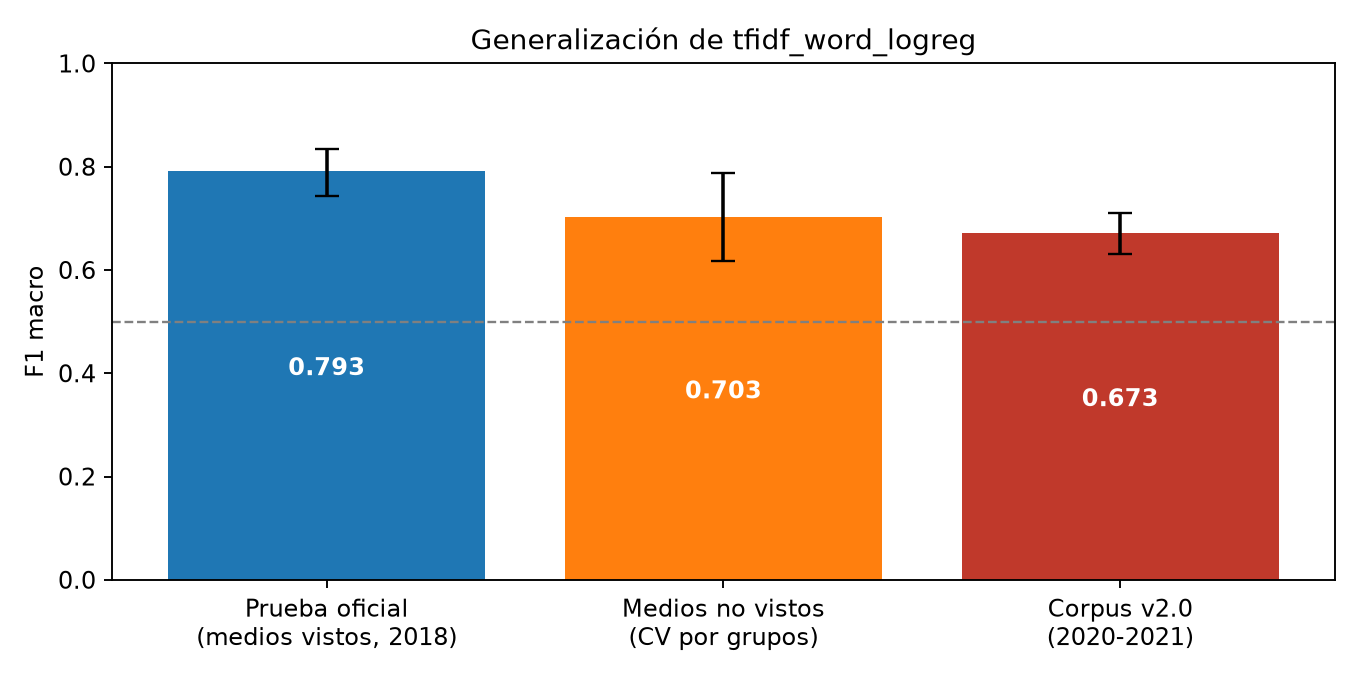

In [ ]:
display(results["robustness"].round(4))
ext = results["external_v2_selected"]
print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v) for k, v in ext.items()}, indent=2))
display(Image(REPORTS / "fig_generalization.png", width=750))

## 6. Análisis de 20 errores
10 falsos negativos y 10 falsos positivos del modelo seleccionado, priorizando los de mayor confianza. Las categorías provienen de la lectura completa de cada texto (`docs/error_categories.csv`).

,id,error_type,topic,source,confidence,words,category,explanation
0,253,FN: verdadera predicha como falsa,Entertainment,Radio Formula,0.7551,178,A. Verdadera con estilo de rumor,"Farándula basada en ""gente del equipo"" y un programa de radio; el texto repite el párrafo inicial. Fuentes indirecta..."
1,173,FN: verdadera predicha como falsa,Politics,Excelsior,0.7296,207,D. Tema compartido entre clases,"Política electoral (Anaya, comunidad gay); el corpus contiene muchas falsas sobre candidatos de 2018 con el mismo vo..."
2,22,FN: verdadera predicha como falsa,Society,Milenio,0.7243,132,C. Verdadera insólita o sensacionalista,Hecho real pero llamativo (hamburguesa vegana) con tono ligero y comparaciones coloquiales.
3,289,FN: verdadera predicha como falsa,Entertainment,EL UNIVERSAL,0.7111,395,D. Tema compartido entre clases,"Farándula y política (Belinda y AMLO) con citas largas en primera persona (""yo"", ""nos""), rasgos que el modelo pesa h..."
4,279,FN: verdadera predicha como falsa,Entertainment,Excelsior,0.6740,446,B. Desmentido que reproduce el bulo,"Noticia verdadera que desmiente un rumor y, para hacerlo, reproduce la afirmación falsa y sus citas. El vocabulario ..."
5,89,FN: verdadera predicha como falsa,Health,El país,0.6635,173,C. Verdadera insólita o sensacionalista,"Titular alarmista de salud (""daña tu salud"") apoyado en Daily Mail; estilo de clickbait aunque la nota es real."
6,152,FN: verdadera predicha como falsa,Sport,ESPN,0.6544,219,A. Verdadera con estilo de rumor,"Se apoya en ""allegados"" y ""nuestro informante""; atribución anónima que el modelo asocia con la clase falsa."
7,124,FN: verdadera predicha como falsa,Sport,El Universal,0.6502,466,B. Desmentido que reproduce el bulo,El embajador aclara una publicación previa sobre máscaras; el texto cita la versión difundida en internet antes de c...
8,126,FN: verdadera predicha como falsa,Sport,EL UNIVERSAL,0.6370,260,A. Verdadera con estilo de rumor,"Tono de columna deportiva sin citas verificables; conectores como ""ahora lo que"" y narración especulativa."
9,148,FN: verdadera predicha como falsa,Sport,Milenio,0.6249,220,A. Verdadera con estilo de rumor,"Titular condicional (""podría salir"") y ""gente cercana al jugador""; especulación de mercado de fichajes."


Errores totales en prueba: 60 de 290


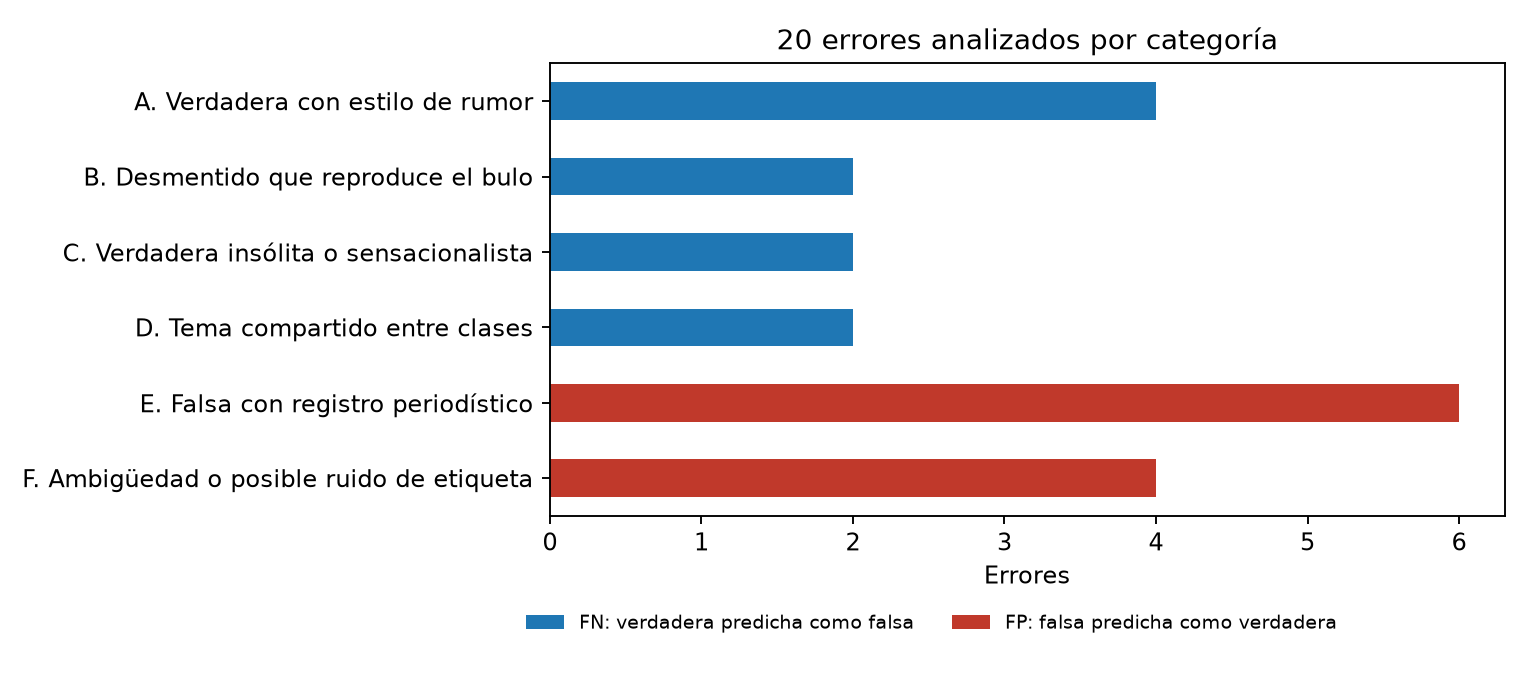

In [ ]:
errors = results["errors"]
display(errors[["id", "error_type", "topic", "source", "confidence", "words", "category", "explanation"]])
print("Errores totales en prueba:", results["errors_in_test_selected"], "de", results["split"]["test_rows"])
display(Image(REPORTS / "fig_error_categories.png", width=800))

## 7. Conclusiones (observación → evidencia → interpretación → decisión)

**Observación.** Ambos pipelines superan con amplitud la línea base (F1 macro 0.79–0.80 frente a 0.32 en prueba).

**Evidencia.** La diferencia entre ellos es pequeña (0.006 en validación cruzada; McNemar p ≈ 0.72) y sus intervalos bootstrap se solapan. Con medios no vistos el F1 baja a ≈ 0.70 y con la v2.0 (2020-2021) a ≈ 0.67, con un recall de `fake` de 0.50.

**Interpretación.** Parte del desempeño en la prueba oficial depende de reconocer el estilo de medios ya vistos y de atajos como la densidad de cifras (`number` pesa hacia `true`). Los falsos positivos más confiados imitan el registro periodístico (cifras, atribución a instituciones); los falsos negativos son notas reales con estilo de rumor o desmentidos que reproducen el bulo. Cuatro errores sugieren ambigüedad de etiqueta.

**Decisión.** Se selecciona `tfidf_word_logreg` por la regla de un error estándar: estadísticamente equivalente al SVM de caracteres, más de 3 veces más rápido de entrenar, más liviano e interpretable. Su uso queda limitado a demostración académica y a priorizar revisión humana; no apto para producción sin evaluación con medios y periodos nuevos.

In [ ]:
print(json.dumps(results["environment"], indent=2))

{
  "python": "3.12.13",
  "platform": "Linux-6.18.44-fc-v70-x86_64-with-glibc2.39",
  "processor": "x86_64",
  "scikit_learn": "1.9.1",
  "pandas": "2.3.3"
}
